# Does losing the Ryder Cup sink your side's stock market? ⛳📉
### The cross-Atlantic "sports-sentiment" folklore — wrong sign, no slump, gone against a coin-flip calendar

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cross--Atlantic_sentiment_shock%3F: Busted](https://img.shields.io/badge/Cross--Atlantic_sentiment_shock%3F-Busted-8b949e?style=flat-square)

Every two years the best golfers of the **United States** play the best of **Europe** for nothing but pride — the Ryder Cup. There's a tidy market story that rides along with it: sport moves mood, mood moves money, so the **losing continent's** stock market should sag the Monday after the Sunday result. It borrows a *real* academic finding — a 2007 study showed national markets genuinely fall when a country's football team is knocked out of the World Cup. The Ryder Cup version swaps one football nation for an entire continent's golf team, and asks whether the same *loss*-driven gloom shows up.

We tested it on every edition with a tradable market on both sides — Team USA as the S&P 500 (`SPY`), Team Europe as a broad Europe ETF (`VGK`).

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the leg decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 23 Ryder Cups hardcoded from Wikipedia (1989 was a tie, no loser). Only the 2006→2025 editions have `VGK` coverage — 10 events. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ryder_cup_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=2.0)
    INC = EV[EV["included"]]
    USA_LOSS = INC[INC["loser"] == "USA"]
    EUR_LOSS = INC[INC["loser"] == "Europe"]
else:
    PRICES = EV = INC = USA_LOSS = EUR_LOSS = None
print("real cache present:", HAVE_REAL, "| editions:", len(data.EVENTS),
      "| resolved events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 23, 'n_contested': 22, 'n_included': 10, 'n_usa_loss': 7, 'n_eur_loss': 3, 'fp': '0d34990aeb50', 'panel_rows': 8411, 'panel_start': '1993-01-29', 'mon_mean': 0.38, 'mon_t': 1.817, 'mon_hit_neg': 2, 'mon_n': 10, 'mon_w_lo': 5.7, 'mon_w_hi': 51.0, 'wk_mean': -0.047, 'wk_t': -0.104, 'wk_hit_neg': 6, 'wk_n': 10, 'wk_w_lo': 31.3, 'wk_w_hi': 83.2, 'pl_mon_p': 0.95, 'pl_mon_mean': 0.006, 'pl_mon_sd': 0.235, 'pl_wk_p': 0.433, 'pl_wk_mean': 0.035, 'pl_wk_sd': 0.477, 'loser_leg_mean': -0.171, 'loser_leg_t': -0.822, 'winner_leg_mean': -0.546, 'winner_leg_t': -1.614, 'asym_welch_t': 0.42, 'usa_loss_mon': 0.424, 'eur_loss_mon': 0.276, 'car': {0: 0.0, 1: 0.38, 2: 0.192, 3: -0.01, 4: 0.109, 5: -0.047}, 'cap_day_g': 0.189, 'cap_day_tg': 1.05, 'cap_day_n2': 0.107, 'cap_day_t2': 0.59, 'cap_day_n5': -0.013, 'cap_day_t5': -0.07, 'cap_wk_g': 0.409, 'cap_wk_tg': 0.81, 'cap_wk_n2': 0.319, 'cap_wk_t2': 0.63, 'cap_wk_n5': 0.199, 'cap_wk_t5': 0.4, 'pl_cap_wk_p': 0.179, 'pl_cap_wk_mean': -0.123, 'syn_null_mean': 0.22, 'syn_null_sd': 0.79, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_planted1_t': -2.23, 'syn_planted2_t': -4.6}


real cache present: True | editions: 23 | resolved events: 10


## The answer first

| Question | Answer |
|---|---|
| Does the losing side's market lag the winner's the Monday after? | **No — if anything the opposite.** The loser-minus-winner spread is **+0.38%** (positive means the *loser* did better), and only **2 of 10** losing continents actually lagged. |
| Is that little wrong-way blip even real? | **No.** A random Monday is *more* likely to show the folklore's dip than the actual Ryder Cup Mondays (placebo *p* = **0.95**), and it's gone by the end of the week. |
| Does the *loser's own* market slump (the football mechanism)? | **No.** The losing side's abnormal Monday return is a flat **-0.17%** — and the *winner's* market actually fell a touch more. |
| Could you have traded it? | **No.** The only tradable version (bet the loser keeps lagging, entered after the result) nets **+0.32%** over a week — statistical noise, on an effect pointing the wrong way. |

> The real football *loss* effect is one of sports finance's tidiest results. It simply does not carry over to a biennial golf match between two continents.

## 1 · The claim

> *"The Ryder Cup is USA vs Europe, played for pride, watched by tens of millions on both sides of the Atlantic. When your continent loses, there's a collective Monday-morning gloom — and gloomy investors sell. The losing side's market should underperform the winner's."*

It rides on real science: Edmans, García & Norli (2007) found that national stock markets really do fall the day after a country is *eliminated* from the football World Cup. Crucially, they found **no** matching *win* effect — losing hurts, winning doesn't help. So the honest Ryder-Cup version is a **loss** story: the losing continent lags. Nobody has ever formally tested it. We did.

## 2 · So what?

If real, this would be a delightful, purely-sentimental, calendar-known edge — short the losing continent, long the winner, every other September. And it would extend a genuine academic finding (football losses) to a second sport. If it's *not* real, it's a clean example of how a true effect in one setting gets over-extended into folklore in another. We wanted to know which.

## 3 · How would we even know?

- **The calendar.** All **23** Ryder Cups of the modern USA-vs-Europe era (1979→2025), hardcoded with winner and loser (1989 was a 14-14 tie — no loser).
- **The market.** Team USA = `SPY` (S&P 500), Team Europe = `VGK` (broad Europe — includes the UK, Switzerland, the Nordics, not just the euro zone). We measure the **loser-minus-winner** return, so the shared global move cancels out.
- **The window.** From the last close before the Sunday result through the Monday and the week after. The folklore predicts a **negative** spread.
- **The honesty checks.** A random-window placebo (does a random Monday do the same?), a decomposition (does the *loser* slump, or the winner?), and a trade you could *actually* have placed.

## 4 · The teardown — let's actually look

**The headline: the Monday spread points the wrong way.**

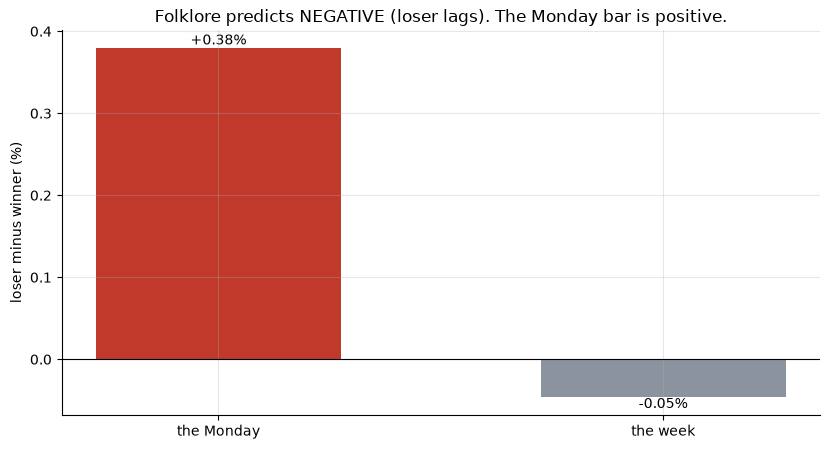

Monday spread +0.380%  |  week spread -0.047%


In [2]:
if HAVE_REAL:
    mon = st.one_sample_t(INC['spread_mon'].values)['mean']*100
    wk = st.one_sample_t(INC['spread_wk'].values)['mean']*100
else:
    mon, wk = R['mon_mean'], R['wk_mean']
fig, ax = plt.subplots(figsize=(8.4, 4.6))
bars = ax.bar(['the Monday', 'the week'], [mon, wk],
              color=[RED, GREY], width=.55)
for b, v in zip(bars, [mon, wk]): ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v),
                                              ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('loser minus winner (%)')
ax.set_title('Folklore predicts NEGATIVE (loser lags). The Monday bar is positive.')
ax.annotate('folklore\nexpects\nthis way', (0, -0.18), color=GREY, ha='center', fontsize=9)
ax.annotate('', xy=(0, -0.28), xytext=(0, -0.05),
            arrowprops=dict(arrowstyle='->', color=GREY))
plt.tight_layout(); plt.show()
print(f'Monday spread {mon:+.3f}%  |  week spread {wk:+.3f}%')

The loser-minus-winner spread on the Monday is **+0.38%** — and *positive* means the **loser did better**, the exact opposite of the claim. It's not big enough to mean anything (*t* = 1.82), but it is not the dip the folklore promises. By the end of the week even that blip is gone (-0.05%).

**And only 2 of 10 losing continents actually lagged at all:**

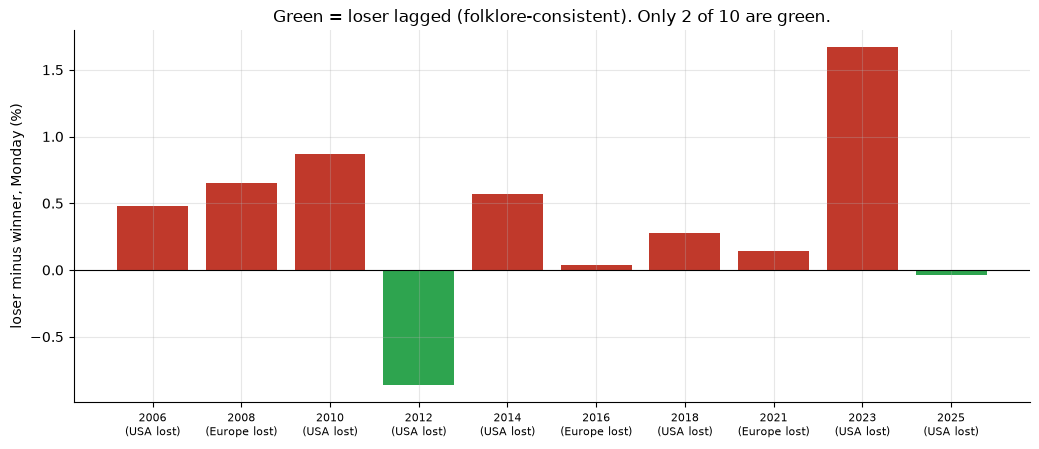

events where the loser lagged (spread<0): 2 of 10


In [3]:
if HAVE_REAL:
    sp = INC['spread_mon'].values*100
    yrs = INC['year'].values; los = INC['loser'].values
else:
    rng = np.random.default_rng(735); sp = rng.normal(0.4, 1.2, 10)
    yrs = [2006,2008,2010,2012,2014,2016,2018,2021,2023,2025]
    los = ['USA','Europe','USA','USA','USA','Europe','USA','Europe','USA','USA']
labels = [f'{y}\n({l} lost)' for y, l in zip(yrs, los)]
fig, ax = plt.subplots(figsize=(10.5, 4.6))
cols = [GREEN if v < 0 else RED for v in sp]
ax.bar(range(len(sp)), sp, color=cols)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(range(len(sp))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('loser minus winner, Monday (%)')
ax.set_title('Green = loser lagged (folklore-consistent). Only 2 of 10 are green.')
plt.tight_layout(); plt.show()
print('events where the loser lagged (spread<0):', int((sp<0).sum()), 'of', len(sp))

Eight of ten Ryder Cups had the *losing* continent's market **beat** the winner's the Monday after. If a real gloom effect were operating, this bar chart would be mostly green (below zero). It's mostly red.

**Is the winner-side even the one that's weak?** The folklore is specifically that the *loser* slumps. Let's split the paired spread back into its two legs — each side's own abnormal move:

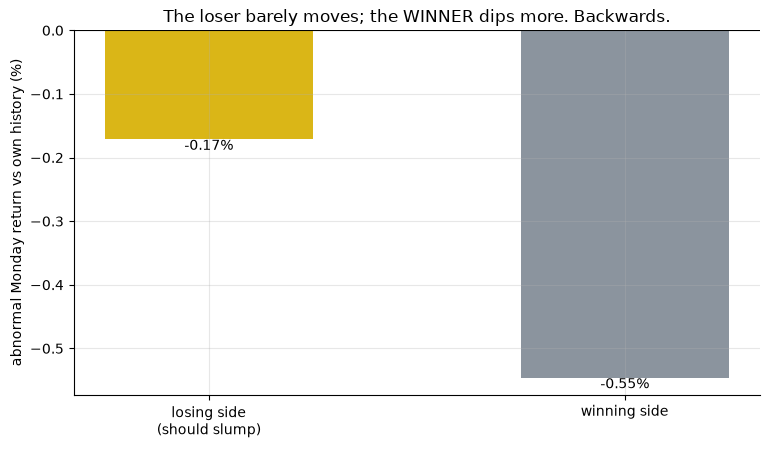

loser leg -0.171%   winner leg -0.546%


In [4]:
if HAVE_REAL:
    ll = st.one_sample_t(INC['loser_ab_mon'].values)['mean']*100
    wl = st.one_sample_t(INC['winner_ab_mon'].values)['mean']*100
else:
    ll, wl = R['loser_leg_mean'], R['winner_leg_mean']
fig, ax = plt.subplots(figsize=(7.8, 4.6))
bars = ax.bar(['losing side\n(should slump)', 'winning side'], [ll, wl],
              color=[AMBER, GREY], width=.5)
for b, v in zip(bars, [ll, wl]): ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v),
                                            ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('abnormal Monday return vs own history (%)')
ax.set_title('The loser barely moves; the WINNER dips more. Backwards.')
plt.tight_layout(); plt.show()
print(f'loser leg {ll:+.3f}%   winner leg {wl:+.3f}%')

There it is: the losing side's own market is a nothing **-0.17%** on the Monday, while the *winning* side's is actually a bit weaker (**-0.55%**). The Edmans mechanism — *losing depresses the loser's market* — is simply absent. Both legs are drifting in the historically soft late-September / early-October window, and the tiny paired gap is just which one drifted less.

**Finally, could you have traded it?**

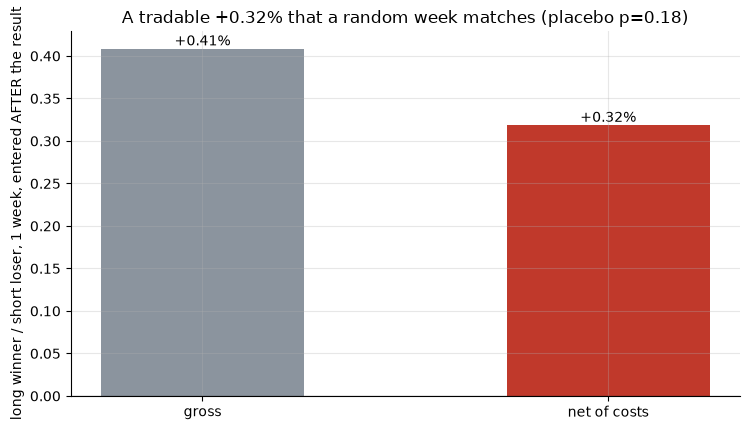

In [5]:
if HAVE_REAL:
    g = st.one_sample_t(INC['cap_week_gross'].values)['mean']*100
    n2 = st.one_sample_t(INC['cap_week_net'].values)['mean']*100
else:
    g, n2 = R['cap_wk_g'], R['cap_wk_n2']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['gross', 'net of costs'], [g, n2], color=[GREY, RED], width=.5)
for i, v in enumerate([g, n2]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('long winner / short loser, 1 week, entered AFTER the result')
ax.set_title('A tradable +0.32% that a random week matches (placebo p=0.18)')
plt.tight_layout(); plt.show()

Betting the loser keeps lagging (long the winner, short the loser, entered the day the result is already public) nets **+0.32%** over a week — positive, but a random week produces that just as easily (placebo *p* = 0.18), and you're trying to trade a pattern whose sign is backwards to begin with. There's no edge here to charge costs against.

## 5 · The verdict

- **Signal — None.** The Monday loser-minus-winner spread is the wrong sign (**+0.38%**, *t* = 1.82), the loser lagged in only 2/10 editions, and a random calendar beats it (placebo *p* = 0.95).
- **Tradability — Mirage.** The only tradable version nets a placebo-normal +0.32% over a week (*t* = 0.63) — noise.
- **Cross-Atlantic sentiment shock? — Busted.** The loser's own market doesn't slump; the winner's leg falls more. The real football *loss* effect does not generalise to the Ryder Cup.

## 6 · Going further 🚪

- **This is over-extension, caught.** A true effect (football *losses* move markets) gets stretched into a folklore claim about a different, much smaller sport — and the tape says no, with the point estimate even pointing the wrong way. Reporting that honestly is the product.
- **The obvious limit is power:** only 10 tradable editions, 7 USA-losses to 3 Europe-losses (VGK doesn't exist before 2005). A believer could push back before 2005 with local European indices instead of a US-listed ETF, or test single-country legs (the losing captain's home market) for a sharper signal.
- **Sibling studies:** the [World Cup effect](../../235-world-cup-effect/) (the real Edmans mechanism it borrows from), the [Eurovision effect](../../708-eurovision-effect/) (the cultural-contest cousin), the [plane-crash effect](../../707-plane-crash-effect/) (the same event-study + placebo machinery, a non-sport mood shock), and the [Super Bowl indicator](../../158-super-bowl/).

*Think the Ryder Cup REALLY moves markets? Build a bigger sample with local European indices back to 1979, or test the losing captain's home market, and show a net, placebo-surviving edge in the right direction. We'll publish the teardown.*